In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

In [2]:
df = pd.read_csv("test1.csv")

print(df.shape)
df.head()

(273, 11)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd,Label
0,3.328337,1374.259799,11.116662,37,4574,11.116662,0,37,501,37,ATTACK
1,3.323688,442.881581,6.619154,22,1472,6.619154,0,22,251,22,ATTACK
2,2.456086,1364.773102,11.400253,28,3352,11.400253,0,28,501,28,ATTACK
3,2.449308,342.954021,5.715900,14,840,5.715900,0,14,253,14,ATTACK
4,2.098657,380329.916123,23.824762,50,798182,23.824762,2,48,64240,33,ATTACK


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                273 non-null    float64
 1   Flow Bytes/s                 273 non-null    float64
 2   Flow Packets/s               273 non-null    float64
 3   Total Fwd Packets            273 non-null    int64  
 4   Total Length of Fwd Packets  273 non-null    int64  
 5   Fwd Packets/s                273 non-null    float64
 6   SYN Flag Count               273 non-null    int64  
 7   ACK Flag Count               273 non-null    int64  
 8   Init_Win_bytes_forward       273 non-null    int64  
 9   act_data_pkt_fwd             273 non-null    int64  
 10  Label                        273 non-null    object 
dtypes: float64(4), int64(6), object(1)
memory usage: 23.6+ KB
None


In [4]:
df.isnull().sum()

Flow Duration                  0
Flow Bytes/s                   0
Flow Packets/s                 0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packets/s                  0
SYN Flag Count                 0
ACK Flag Count                 0
Init_Win_bytes_forward         0
act_data_pkt_fwd               0
Label                          0
dtype: int64

In [5]:
print(df.duplicated().sum())

0


In [6]:
df["Label"].value_counts()

Label
ATTACK    273
Name: count, dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,273.0,3.398258,1.552287,0.020512,2.363949,3.930446,4.887323,4.997224e+00
Flow Bytes/s,273.0,54953.554796,131232.197657,41.344383,404.275461,1604.270801,15064.101075,6.409245e+05
Flow Packets/s,273.0,37.328485,44.875814,0.689073,4.712401,15.020747,62.828308,2.337962e+02
Total Fwd Packets,273.0,125.732601,168.273778,3.000000,8.000000,39.000000,237.000000,7.670000e+02
Total Length of Fwd Packets,273.0,228348.809524,558612.996566,174.000000,741.000000,4404.000000,42540.000000,2.982162e+06
Fwd Packets/s,273.0,37.328485,44.875814,0.689073,4.712401,15.020747,62.828308,2.337962e+02
SYN Flag Count,273.0,68.296703,145.537783,0.000000,0.000000,0.000000,12.000000,7.670000e+02
ACK Flag Count,273.0,57.575092,113.374780,0.000000,5.000000,20.000000,49.000000,6.140000e+02
Init_Win_bytes_forward,273.0,19390.285714,26985.944568,0.000000,501.000000,512.000000,53248.000000,6.553500e+04
act_data_pkt_fwd,273.0,83.630037,147.152203,0.000000,0.000000,8.000000,74.000000,7.670000e+02


In [8]:
df.median(numeric_only=True)

Flow Duration                     3.930446
Flow Bytes/s                   1604.270801
Flow Packets/s                   15.020747
Total Fwd Packets                39.000000
Total Length of Fwd Packets    4404.000000
Fwd Packets/s                    15.020747
SYN Flag Count                    0.000000
ACK Flag Count                   20.000000
Init_Win_bytes_forward          512.000000
act_data_pkt_fwd                  8.000000
dtype: float64

In [9]:
features = [
'Flow Duration',
'Flow Bytes/s',
'Flow Packets/s',
'Total Fwd Packets',
'Total Length of Fwd Packets',
'Fwd Packets/s',
'SYN Flag Count',
'ACK Flag Count',
'Init_Win_bytes_forward',
'act_data_pkt_fwd'
]

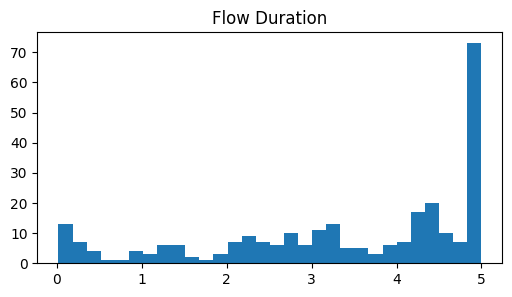

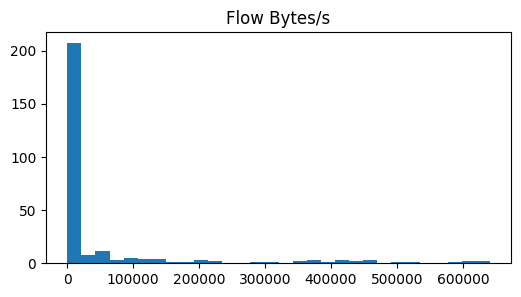

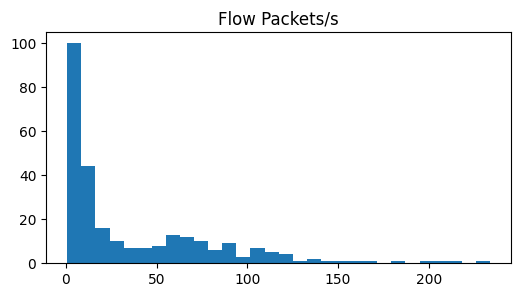

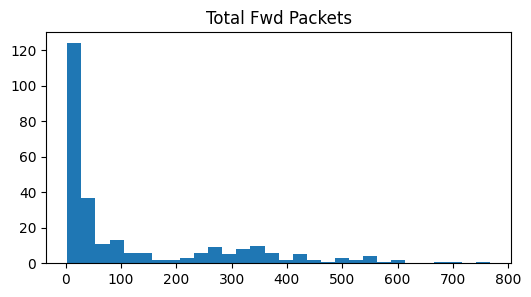

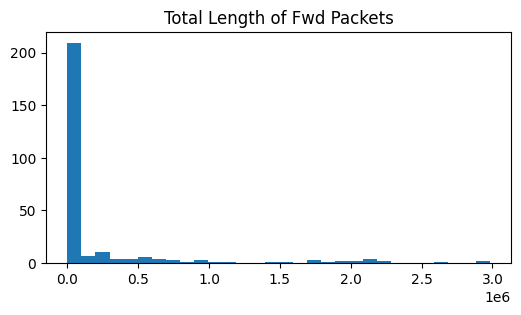

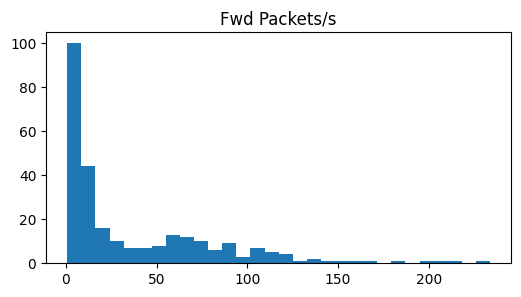

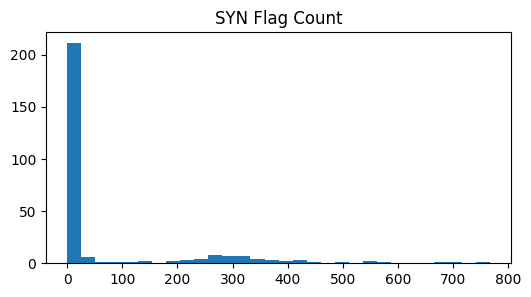

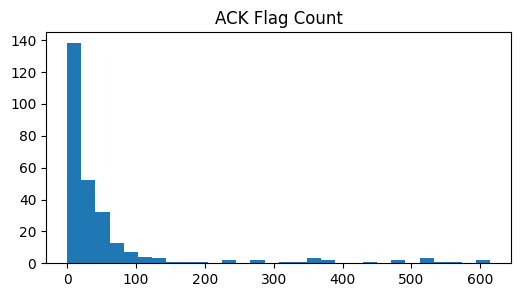

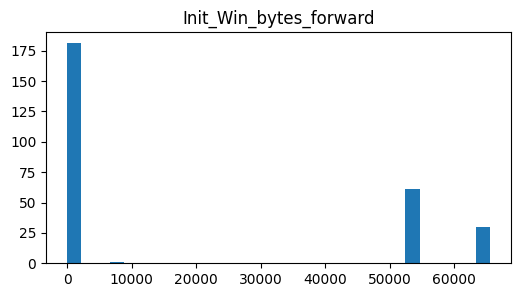

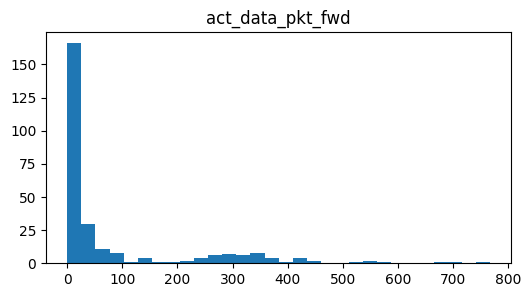

In [10]:
for col in features:

    plt.figure(figsize=(6,3))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.show()

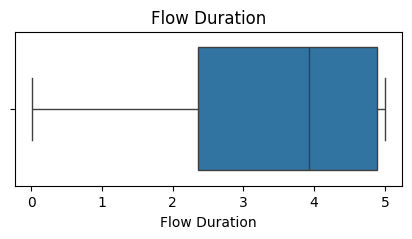

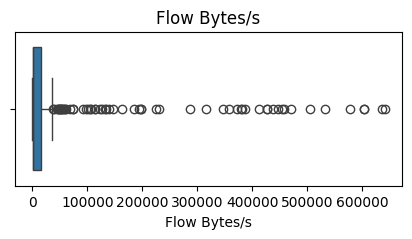

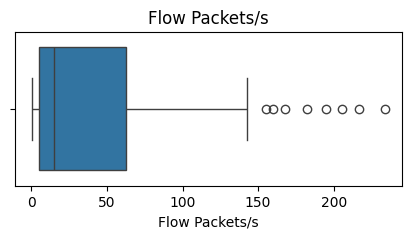

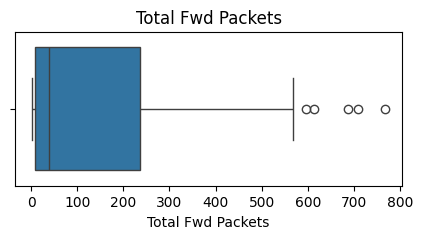

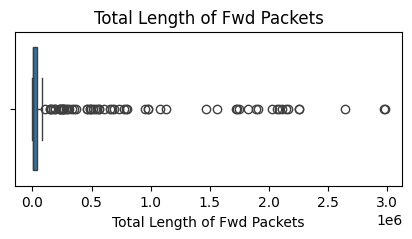

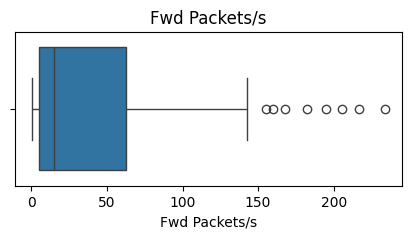

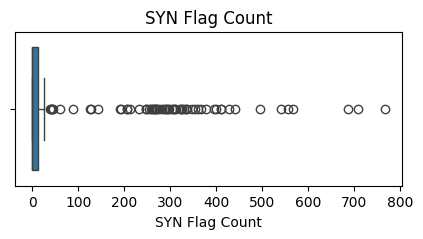

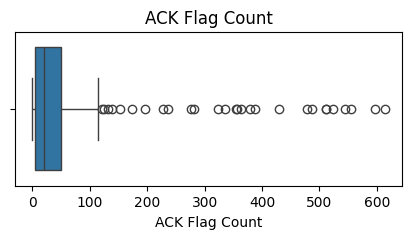

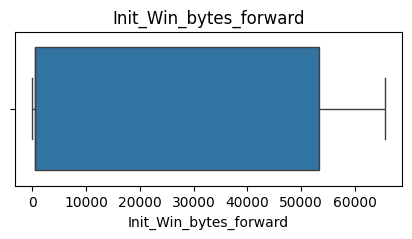

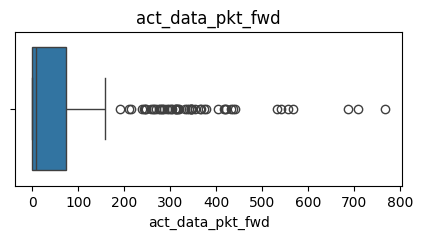

In [11]:
for col in features:

    plt.figure(figsize=(5,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

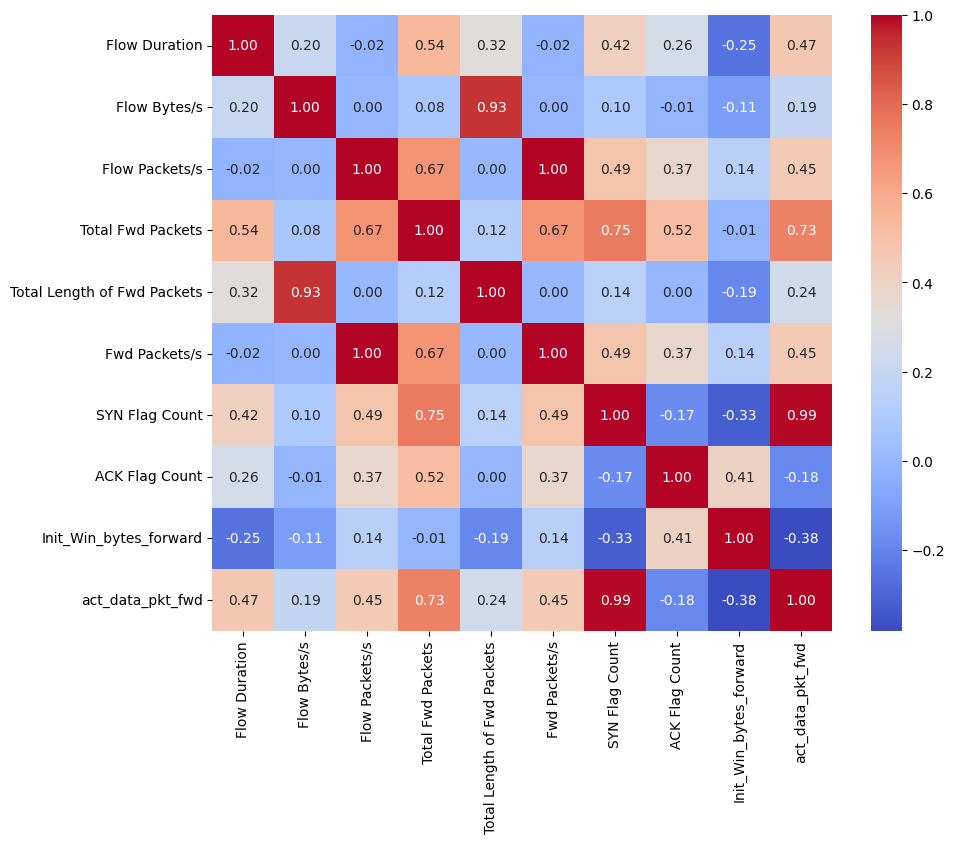

In [12]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [13]:
df[features].var().sort_values()

Flow Duration                  2.409594e+00
Flow Packets/s                 2.013839e+03
Fwd Packets/s                  2.013839e+03
ACK Flag Count                 1.285384e+04
SYN Flag Count                 2.118125e+04
act_data_pkt_fwd               2.165377e+04
Total Fwd Packets              2.831606e+04
Init_Win_bytes_forward         7.282412e+08
Flow Bytes/s                   1.722189e+10
Total Length of Fwd Packets    3.120485e+11
dtype: float64

In [14]:
for col in features:

    print(col)

    print(df[col].nunique())

Flow Duration
273
Flow Bytes/s
273
Flow Packets/s
273
Total Fwd Packets
142
Total Length of Fwd Packets
232
Fwd Packets/s
273
SYN Flag Count
68
ACK Flag Count
102
Init_Win_bytes_forward
16
act_data_pkt_fwd
110


In [15]:
for col in features:

    counts = df[col].value_counts()

    e = entropy(counts)

    print(col, e)

Flow Duration 5.60947179518496
Flow Bytes/s 5.60947179518496
Flow Packets/s 5.60947179518496
Total Fwd Packets 4.459287594031858
Total Length of Fwd Packets 5.343039991175674
Fwd Packets/s 5.60947179518496
SYN Flag Count 2.0555321306240972
ACK Flag Count 4.114549992813201
Init_Win_bytes_forward 2.243852176722071
act_data_pkt_fwd 3.6937629917227897


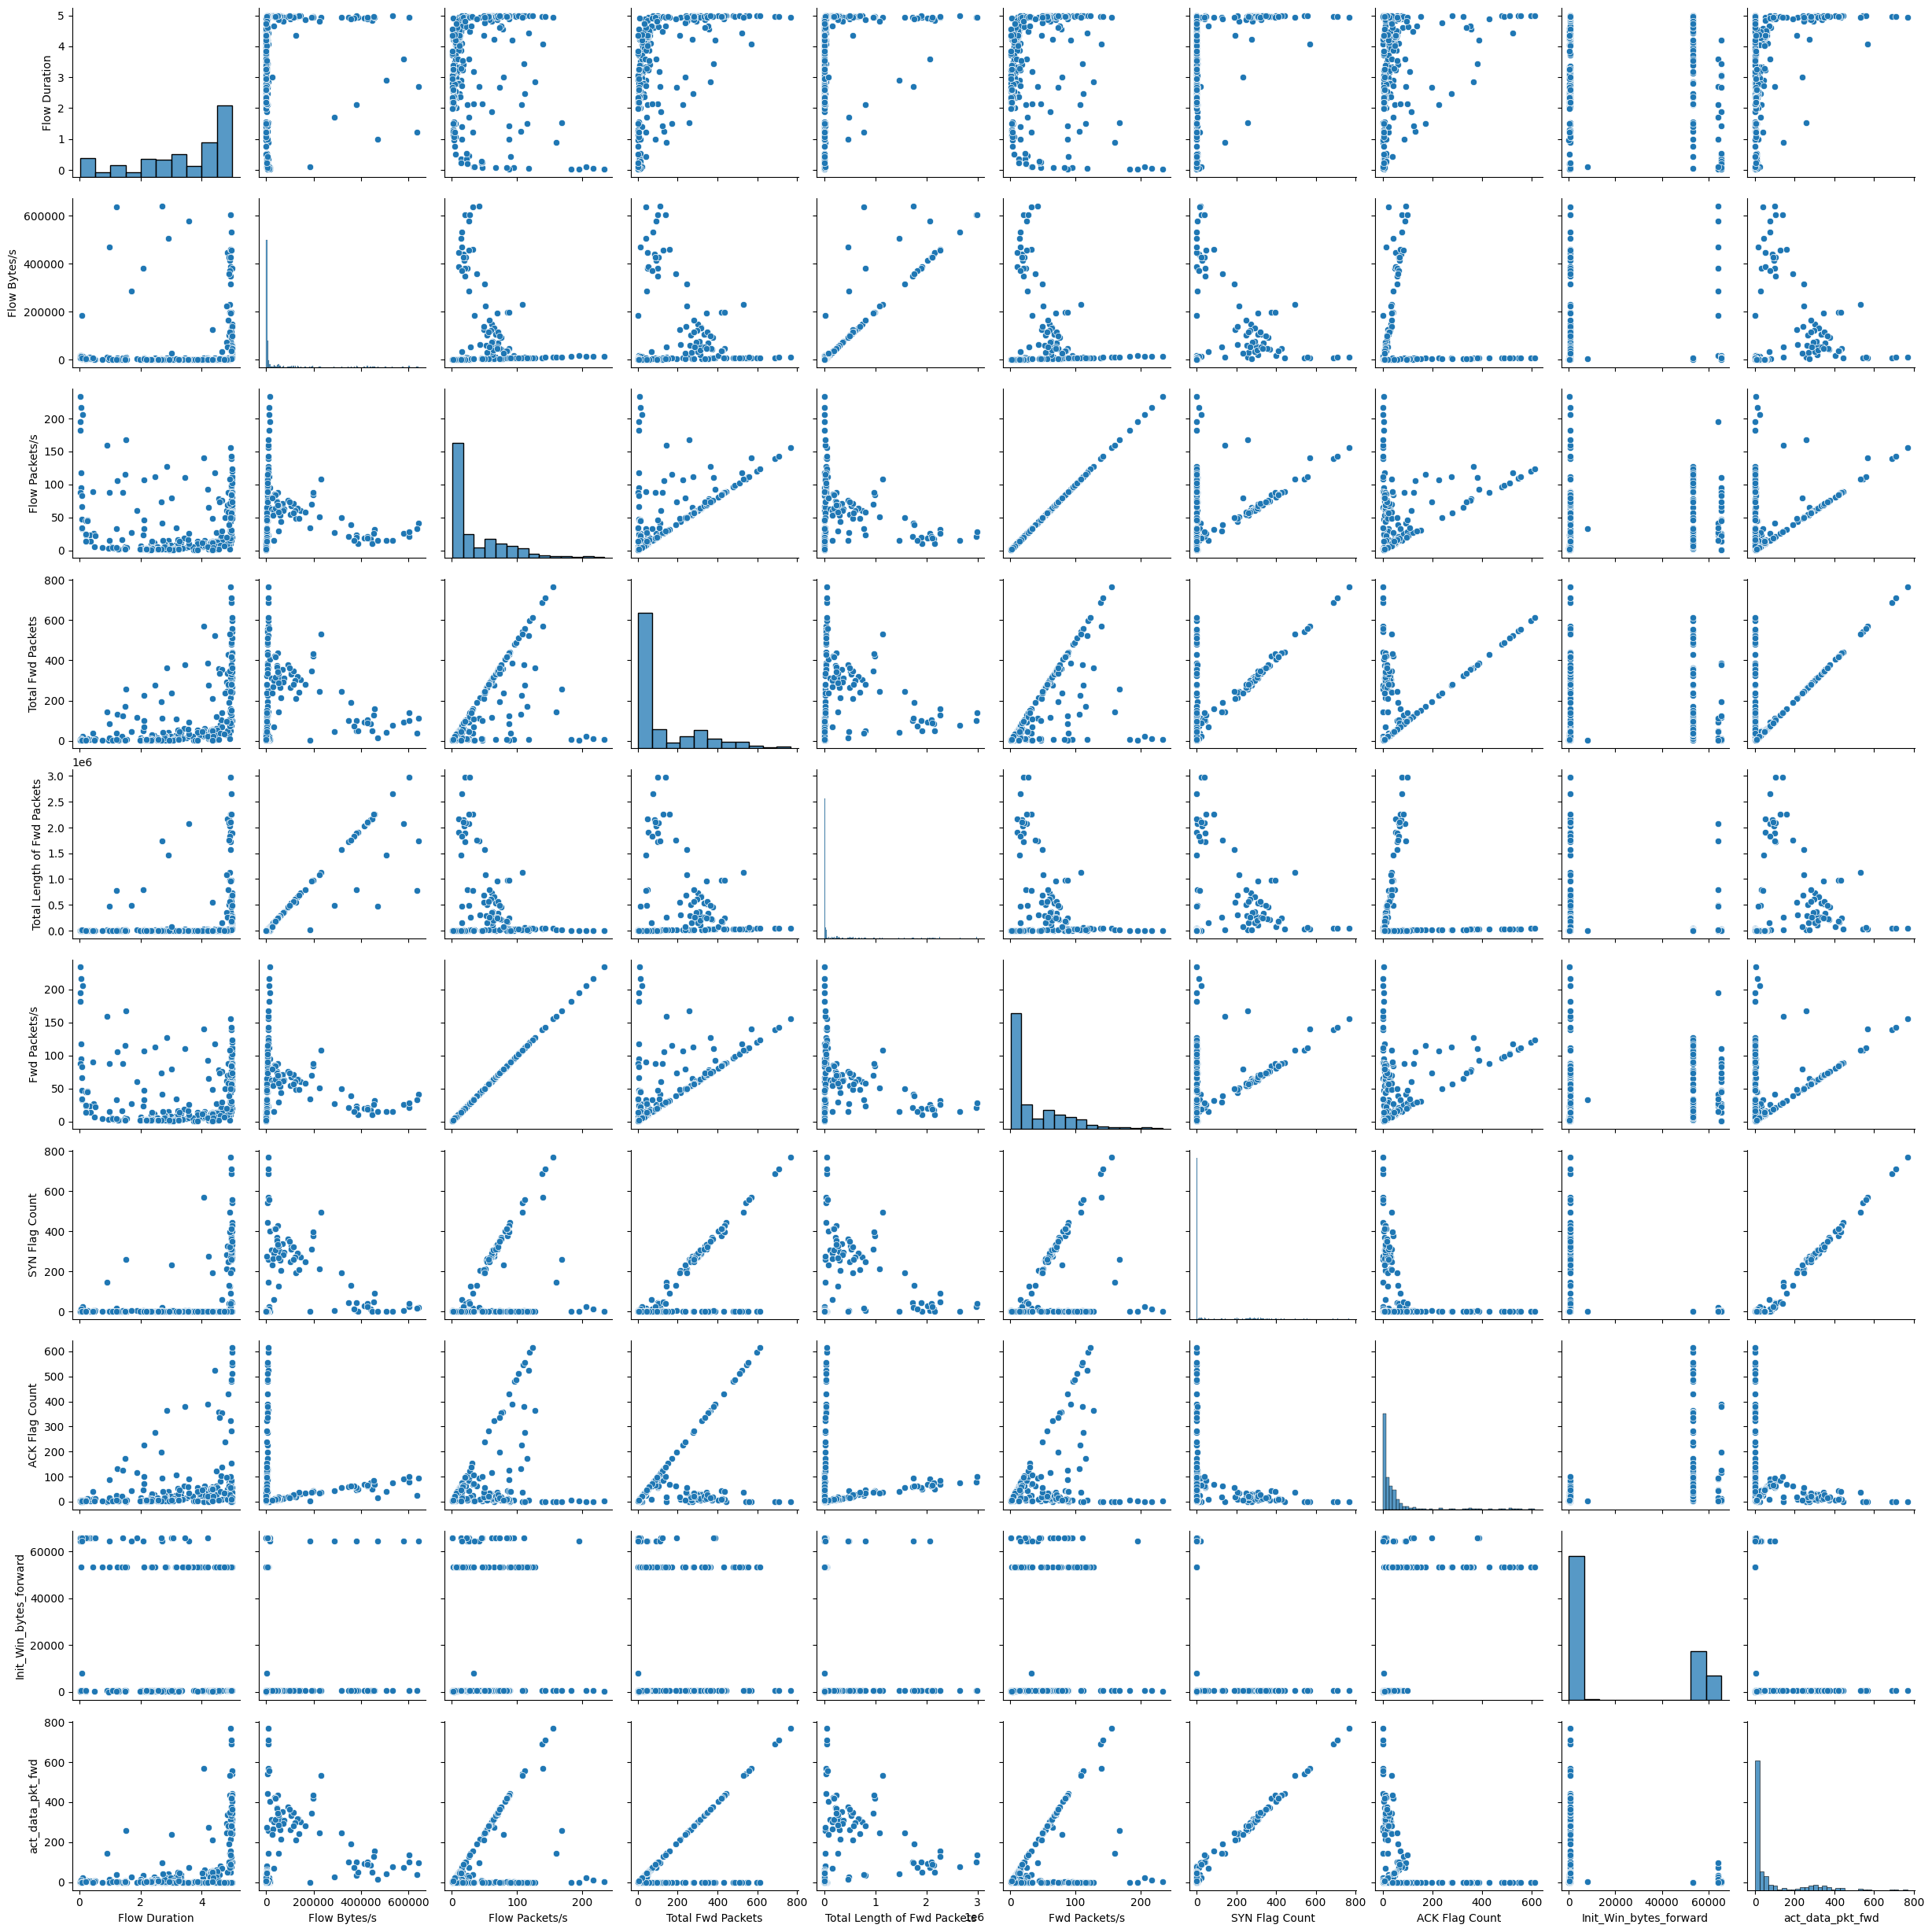

In [16]:
sns.pairplot(
    df[features]
)

In [17]:
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [18]:
X = df[features]

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

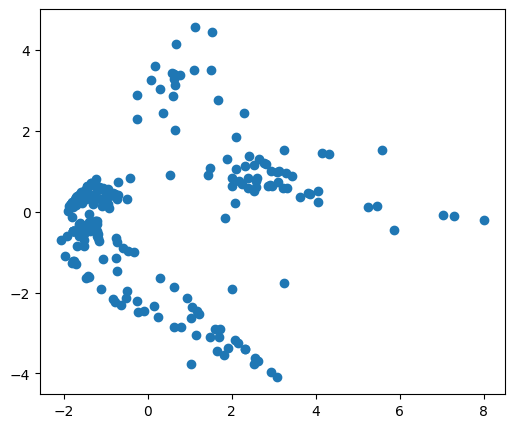

In [19]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.show()

In [20]:
corr = abs(df[features].corr())

corr

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd
Flow Duration,1.000000,0.204975,0.016126,0.539328,0.322003,0.016126,0.420393,0.259842,0.253168,0.468418
Flow Bytes/s,0.204975,1.000000,0.000799,0.077577,0.934359,0.000799,0.095712,0.008225,0.108319,0.190228
Flow Packets/s,0.016126,0.000799,1.000000,0.672319,0.003699,1.000000,0.487021,0.372026,0.135962,0.454294
Total Fwd Packets,0.539328,0.077577,0.672319,1.000000,0.124458,0.672319,0.748118,0.523375,0.005698,0.732569
Total Length of Fwd Packets,0.322003,0.934359,0.003699,0.124458,1.000000,0.003699,0.141952,0.002006,0.190470,0.243339
Fwd Packets/s,0.016126,0.000799,1.000000,0.672319,0.003699,1.000000,0.487021,0.372026,0.135962,0.454294
SYN Flag Count,0.420393,0.095712,0.487021,0.748118,0.141952,0.487021,1.000000,0.173869,0.325105,0.989608
ACK Flag Count,0.259842,0.008225,0.372026,0.523375,0.002006,0.372026,0.173869,1.000000,0.411297,0.183734
Init_Win_bytes_forward,0.253168,0.108319,0.135962,0.005698,0.190470,0.135962,0.325105,0.411297,1.000000,0.380984
act_data_pkt_fwd,0.468418,0.190228,0.454294,0.732569,0.243339,0.454294,0.989608,0.183734,0.380984,1.000000


In [21]:
for col in features:

    print(
        col,
        df[col].std()
    )

Flow Duration 1.5522866378571214
Flow Bytes/s 131232.1976571914
Flow Packets/s 44.875814086572035
Total Fwd Packets 168.2737777081361
Total Length of Fwd Packets 558612.9965664173
Fwd Packets/s 44.875814086572035
SYN Flag Count 145.53778273124504
ACK Flag Count 113.3747804755432
Init_Win_bytes_forward 26985.944567722378
act_data_pkt_fwd 147.15220253917713
